### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

### Load Preprocessed Data

In [3]:
print(X_train.shape)
print(X_test.shape)

(1600000, 23)
(400000, 23)


### Model 1 — Linear Regression (Baseline)

In [4]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

#### Evaluating the model

In [5]:
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 4.236896109113315
Linear Regression MAE: 2.186394846693201
Linear Regression R2: 0.020750393758141583


### Model 2 — Random Forest (Nonlinear Model)

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

#### Evaluating the model

In [7]:
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 4.167342916758325
Random Forest MAE: 2.038406177482
Random Forest R2: 0.05263736274304798


### Model 3 — Gradient Boosting

In [8]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

#### Evaluating the model

In [9]:
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
mae_gb = mean_absolute_error(y_test, pred_gb)
r2_gb = r2_score(y_test, pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting R2:", r2_gb)

Gradient Boosting RMSE: 4.089477225387851
Gradient Boosting MAE: 1.9851644757441569
Gradient Boosting R2: 0.08770905681166918


### Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "R2":[r2_lr, r2_rf, r2_gb]
    })

results

,Model,RMSE,MAE,R2
0,Linear Regression,4.236896,2.186395,0.020750
1,Random Forest,4.167343,2.038406,0.052637
2,Gradient Boosting,4.089477,1.985164,0.087709


### Based on comparision Gradient Boosting model looks the best, with lowest RMSE and MAE. 

### Feature Importance (For Gradient Boosting)

In [22]:
gb_importances = gb.feature_importances_

gb_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_importances
}).sort_values("Importance", ascending=False)

gb_importance_df.head(10)

,Feature,Importance
0,sell_price,0.813118
1,year,0.079401
2,week_of_year,0.049520
11,day_of_week_6,0.021638
10,day_of_week_5,0.018583
3,snap_CA,0.006701
9,day_of_week_4,0.003470
19,month_9,0.001881
6,day_of_week_1,0.001466
7,day_of_week_2,0.001150


Feature importance analysis shows that sell_price is the most influential variable, accounting for over 80% of model importance. This indicates that pricing plays a dominant role in predicting product sales. Temporal features such as year and week_of_year also contribute to the model, reflecting seasonal sales patterns.

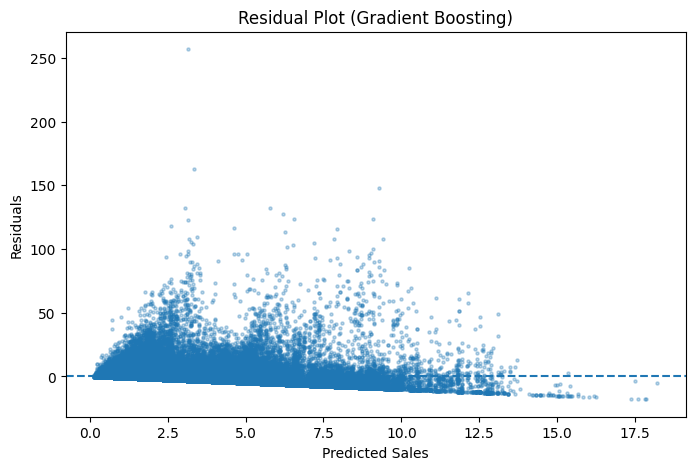

In [23]:
residuals = y_test - pred_gb

plt.figure(figsize=(8,5))
plt.scatter(pred_gb, residuals, alpha=0.3, s=5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot (Gradient Boosting)")
plt.show()

The residual plot shows that most residuals are centered around zero, indicating that the model predictions are generally unbiased. However, there is some dispersion at higher predicted sales values, suggesting that the model struggles slightly with larger sales spikes.

## Summary

### Gradient Boosting performs the best.
- Lowest RMSE
- Lowest MAE
- Handles non-linear relationships better than linear regression.
- sell_price is the most influential variable, accounting for over 80% of model importance

Gradient Boosting achieved the lowest RMSE (4.09) and MAE (2.00), indicating better predictive performance compared to Linear Regression and Random Forest. This suggests the relationship between features and sales is nonlinear, which tree-based ensemble methods can capture more effectively.